In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, silhouette_score
from sklearn.decomposition import PCA
from scipy.stats import chi2
from sklearn.mixture import GaussianMixture

# Classificador

In [2]:
def matriz_conf(y_true, y_pred, labels):
    total_labels = labels
    print(total_labels)
    cm = np.zeros((len(total_labels),len(total_labels)), dtype=int)
    for i in range(len(y_true)):
        cm[y_true[i]][y_pred[i]] += 1
    
    cm = pd.DataFrame(cm, columns=total_labels, index=total_labels)

    cm_transp = pd.DataFrame(np.transpose(cm.to_numpy()), columns=total_labels, index=total_labels)

    for c in cm_transp.columns:
        cm_transp[c] = cm_transp[c]/cm_transp[c].sum()

    cm_porcento = pd.DataFrame(np.transpose(cm_transp.to_numpy()), columns=total_labels, index=total_labels)

    return cm, cm_porcento

def acc(cm, hidden_classes):
    cm_transp = pd.DataFrame(np.transpose(cm.dropna().to_numpy()), columns=cm.columns, index=cm.columns)
    acc = 0
    total = 0
    for c in cm_transp.columns:
        if c not in hidden_classes:
            acc += cm_transp[c][c]
        else:
            acc += cm_transp[c][-1]
        total += cm_transp[c].sum()
    return acc/total

# Calcula CM para todos

In [3]:
filenames = [0,2,3,4,5]

labels_str = ['DDoS', 'Benign', 'DoS', 'BruteForce', 'Bot', 'Web']

filenames

# pd.set_option('future.no_silent_downcasting', True)

[0, 2, 3, 4, 5]

0


Label
1    514148
2    329224
3    243806
4    183163
5       596
Name: count, dtype: int64

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


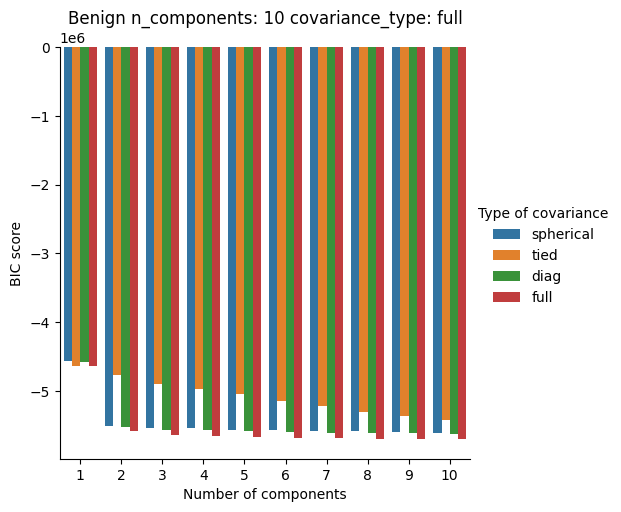

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


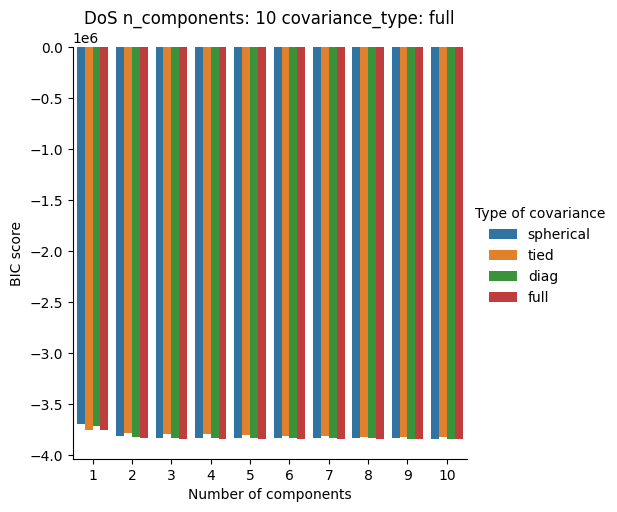

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 8 covariance_type: full


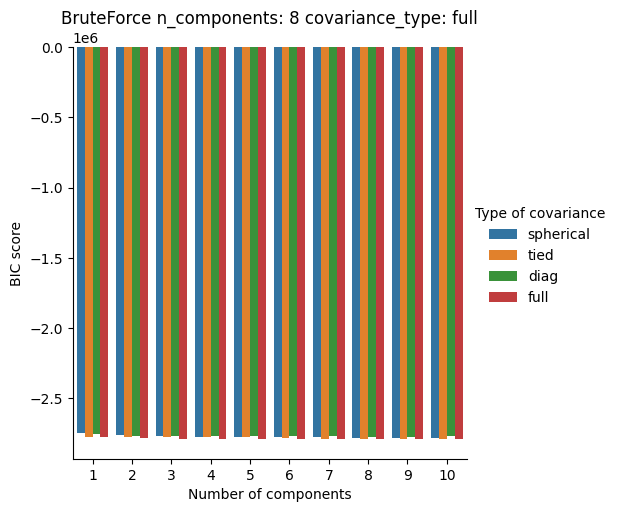

Tipo: 4 = Bot
Melhor modelo: n_componentes: 8 covariance_type: full


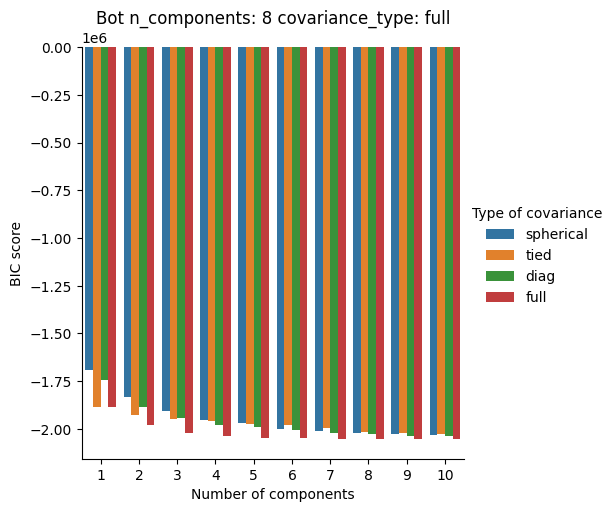

Tipo: 5 = Web
Melhor modelo: n_componentes: 9 covariance_type: spherical


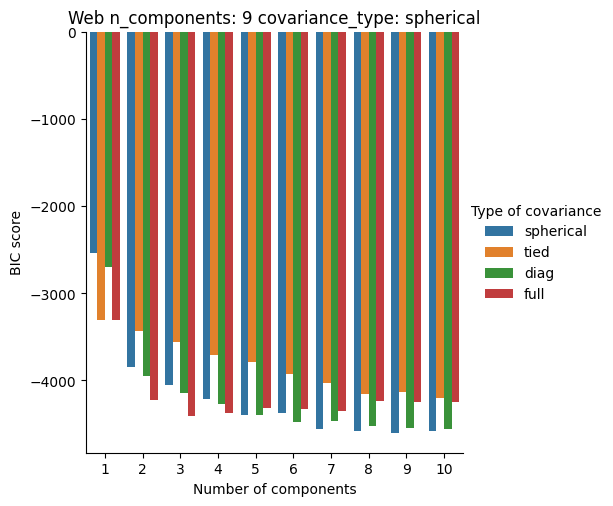

,0,1,2,3,4,5
0,NaN,27.974108,12.123665,-101.951572,19.659321,6.022822
1,NaN,8.228096,29.635784,-19.338302,-76.217779,4.864260
2,NaN,28.527218,12.268387,-99.018214,19.610672,6.050954
3,NaN,6.905009,9.686310,28.544006,-13.947126,3.651167
4,NaN,28.822778,12.756312,-88.849781,19.091996,6.015758
...,...,...,...,...,...,...
519951,NaN,28.442022,12.461887,-103.669148,18.898584,5.922167
519952,NaN,14.319505,-106.122178,-104.383670,29.147749,19.118827
519953,NaN,28.201739,13.528095,-75.427709,18.902925,6.015934
519954,NaN,28.667025,11.808480,-99.120978,19.408751,6.140757


,0,1,2,3,4,5
0,NaN,28.149685,13.549426,-74.916499,18.897728,6.020391
1,NaN,27.965352,12.100970,-101.794452,19.661926,6.025972
2,NaN,27.890983,13.416975,-82.942921,18.622014,6.017220
3,NaN,28.714297,12.755431,-93.409123,19.328105,5.981997
4,NaN,23.182139,11.923924,-74.144846,16.198940,5.966134
...,...,...,...,...,...,...
649942,NaN,28.885283,12.856192,-88.051672,19.107007,6.024882
649943,NaN,22.536790,11.279953,-69.469788,16.941699,5.830306
649944,NaN,22.865122,11.475552,-72.231660,16.750475,5.861453
649945,NaN,7.122973,10.481265,28.946550,-12.921887,3.784191


2


Label
0    808919
1    514148
3    243806
4    183163
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


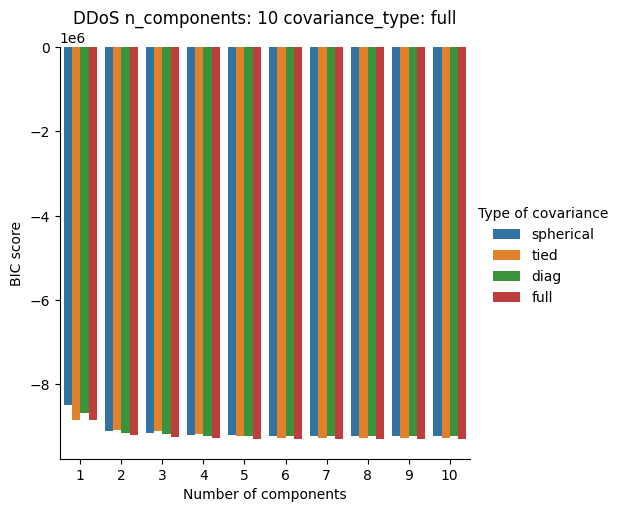

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


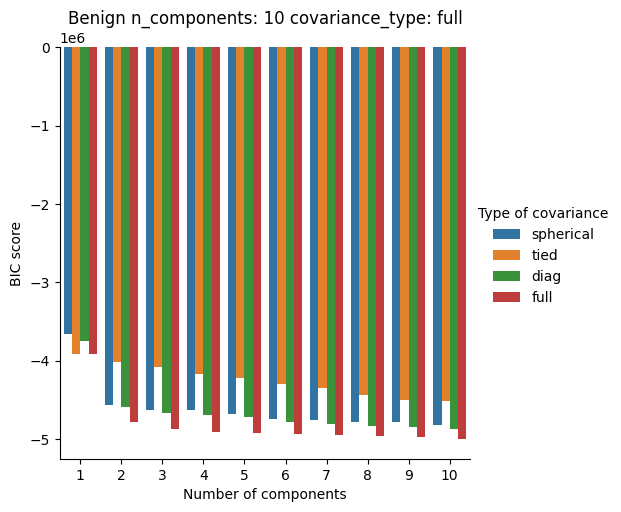

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 10 covariance_type: full


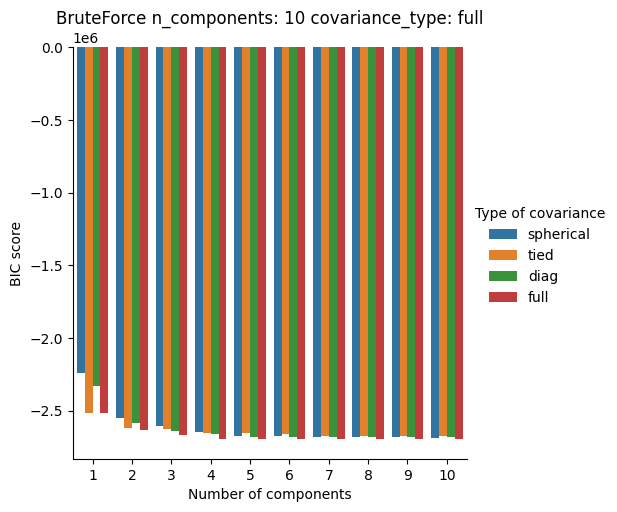

Tipo: 4 = Bot
Melhor modelo: n_componentes: 7 covariance_type: full


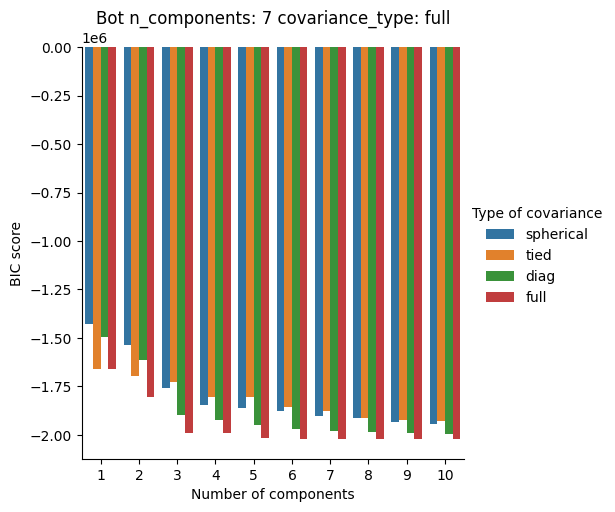

Tipo: 5 = Web
Melhor modelo: n_componentes: 10 covariance_type: diag


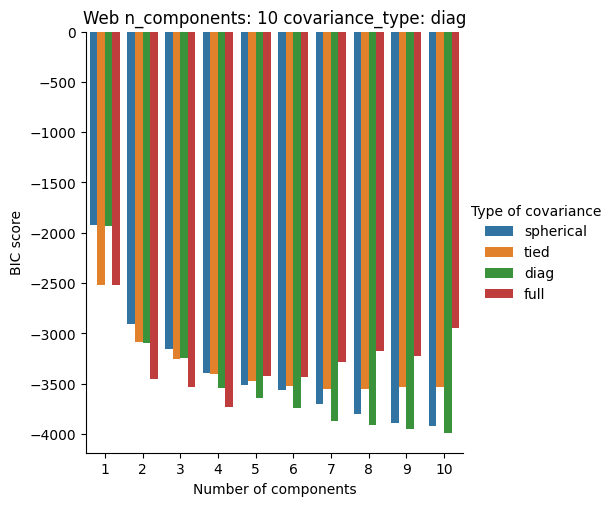

,0,1,2,3,4,5
0,28.918904,9.539501,NaN,-490.175758,5.556974,-5.444003
1,-57.297227,10.121353,NaN,-57.489016,-15.229572,-22.953242
2,-15.050512,25.826052,NaN,-442.377297,10.664938,4.508480
3,-1298.044973,-6.913218,NaN,27.970714,-107.351649,-38.538107
4,-0.818577,26.947754,NaN,-355.492526,10.744060,2.885129
...,...,...,...,...,...,...
519951,1.649483,24.552055,NaN,-359.021417,11.405457,3.839448
519952,-335.741165,12.930935,NaN,-475.537943,29.141088,16.667045
519953,29.275781,10.626571,NaN,-491.609035,4.668853,-5.936437
519954,-9.275765,24.935790,NaN,-364.302016,10.159606,2.037911


,0,1,2,3,4,5
0,29.280335,10.509782,NaN,-491.430082,4.743906,-5.671806
1,29.083928,10.164038,NaN,-490.057368,5.539170,-5.613729
2,8.257639,20.096869,NaN,-282.309052,11.565666,2.120654
3,-97.206100,14.586075,NaN,-795.153289,4.411340,4.129975
4,28.472554,10.698794,NaN,-465.252167,5.978265,-5.984200
...,...,...,...,...,...,...
649942,-2.211004,26.821450,NaN,-358.023649,10.886684,2.934653
649943,27.909923,10.341782,NaN,-465.651808,6.197874,-5.062954
649944,28.493366,10.640545,NaN,-469.559200,6.024395,-5.418680
649945,-1319.630287,-7.286185,NaN,27.880898,-107.877757,-36.461705


3


Label
0    808919
1    514148
2    329224
4    183163
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 9 covariance_type: full


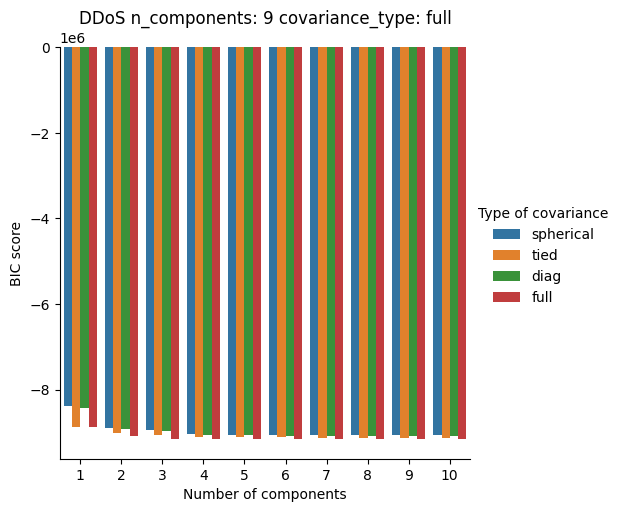

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


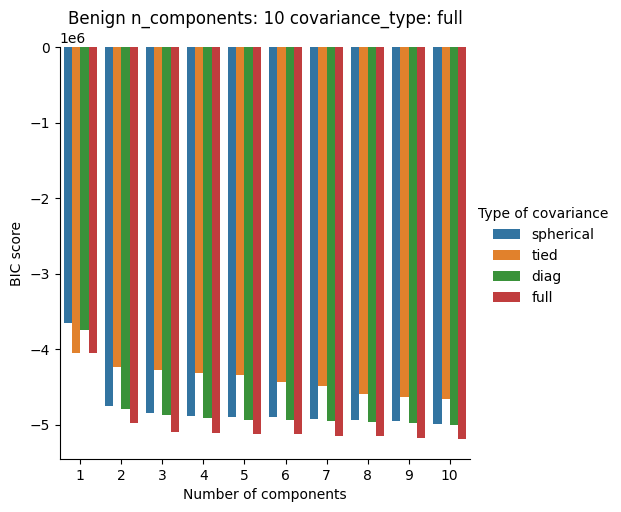

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


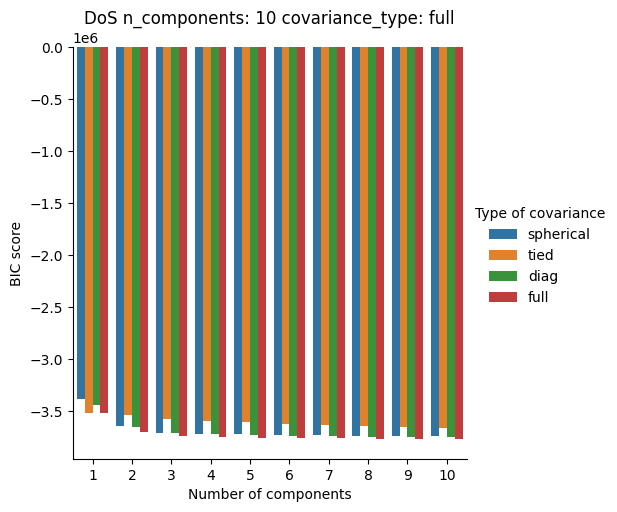

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


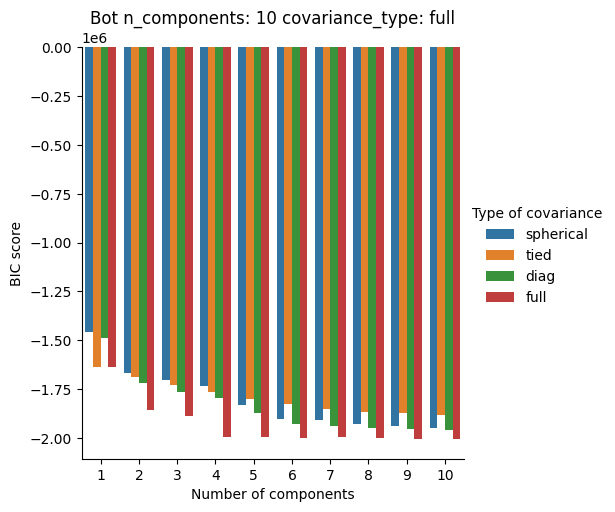

Tipo: 5 = Web
Melhor modelo: n_componentes: 6 covariance_type: full


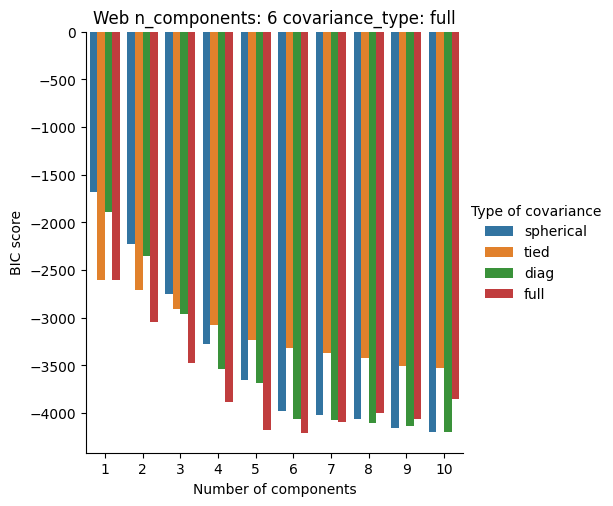

,0,1,2,3,4,5
0,28.611954,15.041707,-34.914566,NaN,3.852079,12.122421
1,-248.991586,10.206042,29.509716,NaN,-52.690083,-103.450402
2,-4.625293,25.918294,0.909732,NaN,11.129127,10.564638
3,-209.068550,11.486265,18.282141,NaN,-45.771019,-88.970413
4,7.656572,27.006130,-1.228440,NaN,10.823422,7.889714
...,...,...,...,...,...,...
519951,5.720688,27.133062,-1.622629,NaN,10.349723,7.825588
519952,-401.427820,8.057225,-188.631882,NaN,28.837648,7.887953
519953,28.934774,15.357289,-28.960466,NaN,4.900998,12.374074
519954,-12.270756,26.886867,-4.863200,NaN,8.951783,14.889973


,0,1,2,3,4,5
0,29.024770,15.360041,-29.416027,NaN,4.913475,12.393699
1,28.002453,15.006147,-37.508375,NaN,3.699485,11.936071
2,8.591205,23.959528,2.891368,NaN,10.577187,0.435081
3,-21.681175,17.580483,-38.110906,NaN,12.484110,16.275741
4,28.302642,15.324191,-26.933266,NaN,5.248892,12.744407
...,...,...,...,...,...,...
649942,3.620775,27.481830,-2.233655,NaN,10.210417,12.026916
649943,27.900812,15.326701,-28.958216,NaN,5.139404,12.728459
649944,28.180089,15.282590,-30.462678,NaN,4.682916,12.878494
649945,-405.095762,6.905274,8.689558,NaN,-106.271078,-126.155177


4


Label
0    808919
1    514148
2    329224
3    243806
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 8 covariance_type: full


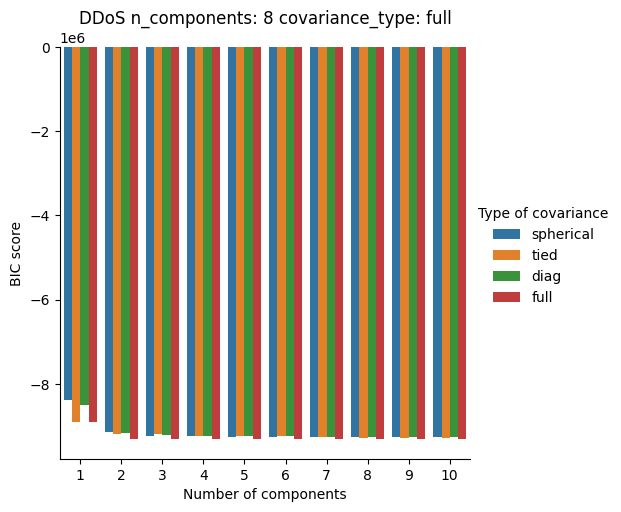

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


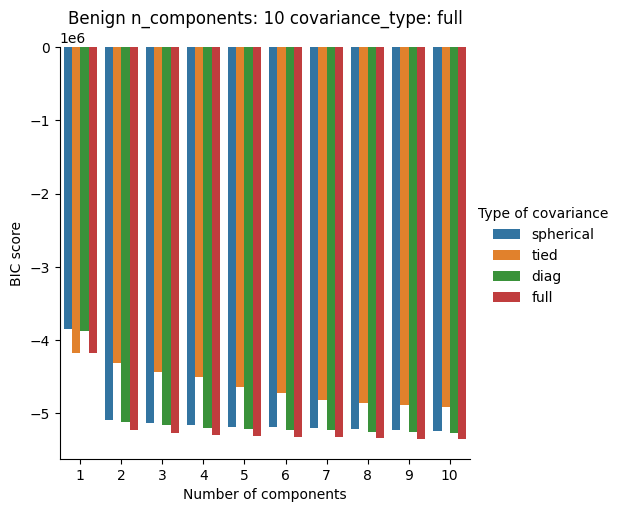

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


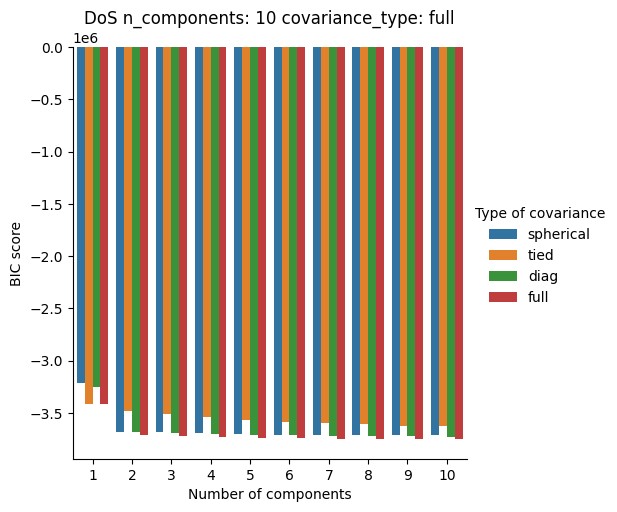

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 10 covariance_type: full


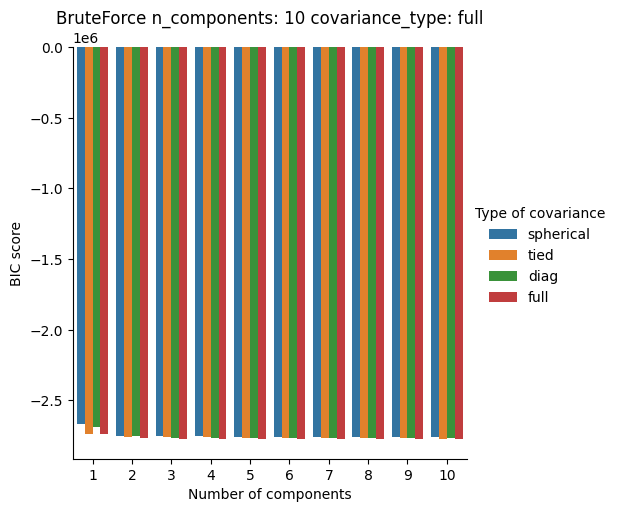

Tipo: 5 = Web
Melhor modelo: n_componentes: 7 covariance_type: diag


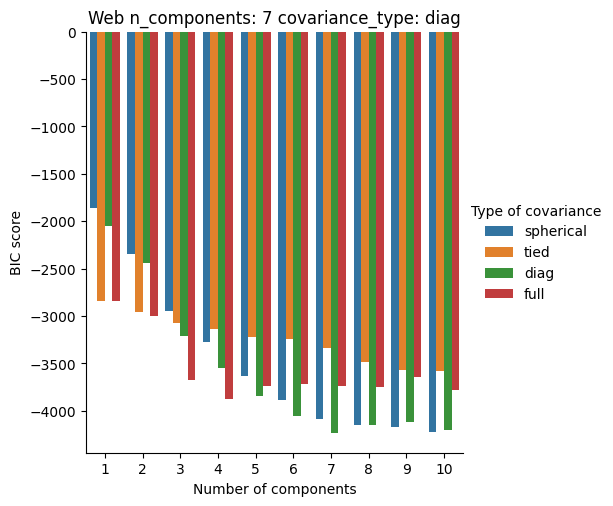

,0,1,2,3,4,5
0,28.892079,15.943640,-8.238359,-975.276204,NaN,7.233414
1,-68.685877,7.751108,29.542669,17.539023,NaN,5.391433
2,11.621974,27.411685,3.660725,-702.331035,NaN,7.916184
3,-145.139000,6.720762,-15.856687,27.785410,NaN,4.825858
4,16.353592,27.852625,3.555607,-715.765323,NaN,7.930451
...,...,...,...,...,...,...
519951,6.418588,25.903046,3.042120,-759.550517,NaN,7.930100
519952,8.987556,19.209430,4.909896,-635.459014,NaN,7.611579
519953,29.147653,20.292767,-9.367389,-1000.970397,NaN,7.162614
519954,17.818988,27.512135,2.069793,-750.671069,NaN,7.890814


,0,1,2,3,4,5
0,29.195694,20.073069,-9.328538,-1003.686746,NaN,7.178790
1,28.472241,14.305371,-8.029015,-971.853644,NaN,7.250961
2,7.304109,22.263916,6.134514,-619.325580,NaN,8.071888
3,12.615691,24.605630,4.278090,-689.420169,NaN,8.041632
4,28.021448,13.711131,-7.219281,-962.041880,NaN,7.299926
...,...,...,...,...,...,...
649942,15.813804,27.794203,3.527848,-715.725057,NaN,7.905435
649943,27.909537,13.843789,-6.735607,-948.084919,NaN,7.306267
649944,28.252086,14.293554,-7.176509,-958.154496,NaN,7.292255
649945,-152.213208,6.268786,-18.623825,28.888308,NaN,4.537712


5


Label
0    808919
1    514148
2    329224
3    243806
4    183163
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


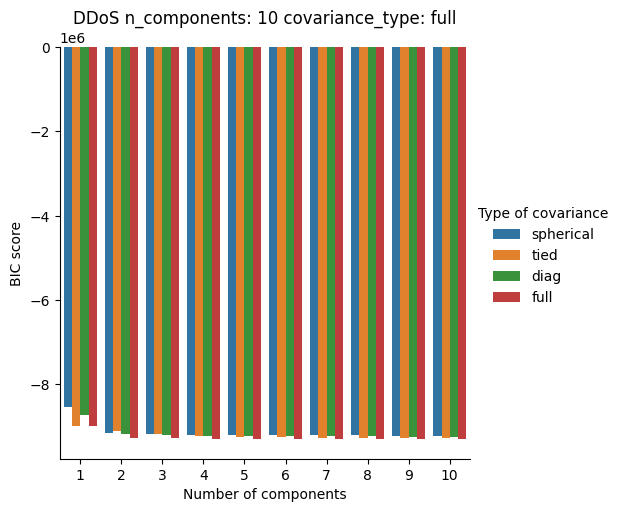

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


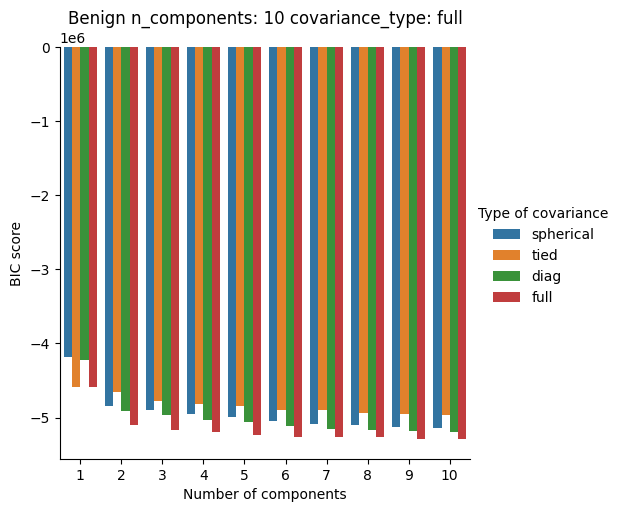

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


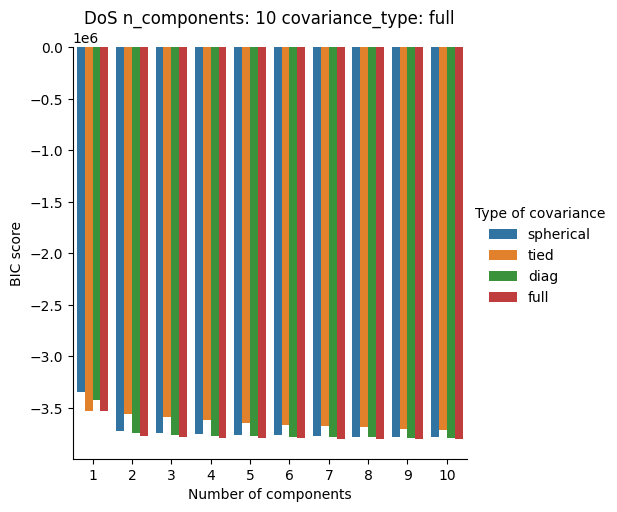

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 10 covariance_type: full


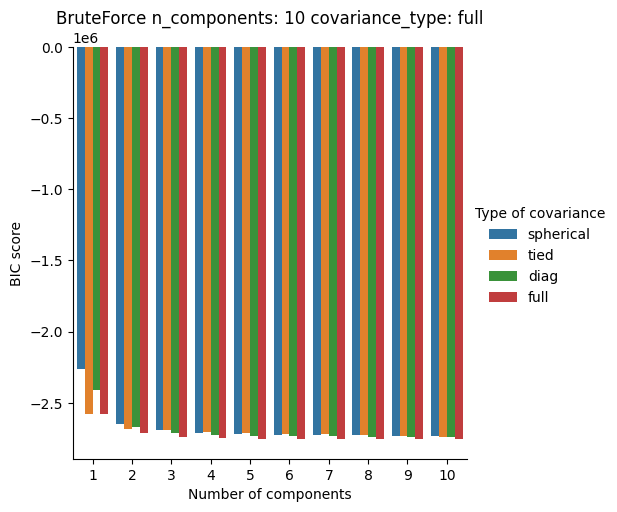

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


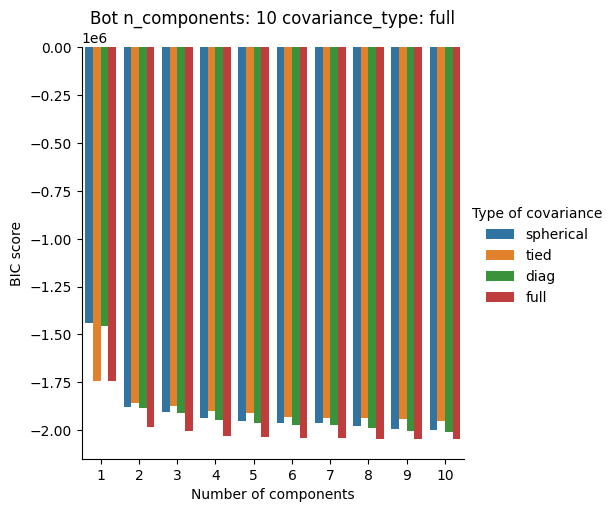

,0,1,2,3,4,5
0,28.630205,10.661519,-16.630961,-118.114638,-12.756149,NaN
1,-778.649333,12.009469,29.657289,-9.825905,-353.091512,NaN
2,-21.656509,25.435728,-15.609167,-1131.462967,18.614107,NaN
3,-1973.890932,8.373412,-78.140480,28.988540,-574.709638,NaN
4,-29.130695,27.727980,-21.475346,-1053.525255,19.281324,NaN
...,...,...,...,...,...,...
519951,-25.719369,26.370553,-16.860010,-1101.402617,18.432302,NaN
519952,-552.161802,12.096763,-4137.359055,-5366.005649,28.909693,NaN
519953,29.200358,12.362564,-15.219887,-125.514957,-7.901770,NaN
519954,-21.622689,26.286403,-19.266614,-1172.524385,17.463118,NaN


,0,1,2,3,4,5
0,29.233440,12.647312,-15.164318,-126.188883,-7.368734,NaN
1,28.507997,10.599440,-16.921483,-117.802646,-13.267871,NaN
2,-37.422448,24.216581,-17.846340,-1003.940009,15.890785,NaN
3,-27.348089,27.068339,-22.792935,-1125.806173,19.439301,NaN
4,29.074695,11.066050,-17.191963,-124.571916,-8.775726,NaN
...,...,...,...,...,...,...
649942,-29.269902,27.678020,-22.006790,-1058.874629,19.398856,NaN
649943,28.739305,12.099954,-16.881264,-127.637945,-6.809612,NaN
649944,28.906744,11.851403,-16.998305,-127.008895,-7.338400,NaN
649945,-1928.150126,8.428378,-75.590533,28.624481,-562.064123,NaN


In [4]:
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import os

def gmm_bic_score(estimator, X):
    """Callable to pass to GridSearchCV that will use the BIC score."""
    # Make it negative since GridSearchCV expects a score to maximize
    return -estimator.bic(X)


param_grid = {
    "n_components": range(1, 11),
    "covariance_type": ["spherical", "tied", "diag", "full"],
    "random_state": [123],
}

exp_train = []
exp_val = []
exp_test = []
y_true_all_exp_train = []
y_true_all_exp_val = []
y_true_all_exp_test = []
for z in range(len(filenames)):
    
    train_encoded_df = pd.read_csv(f'train_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    val_encoded_df = pd.read_csv(f'val_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    test_encoded_df = pd.read_csv(f'test_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    y_true_all_exp_train.append(train_encoded_df['Label'].values.tolist())
    y_true_all_exp_val.append(val_encoded_df['Label'].values.tolist())
    y_true_all_exp_test.append(test_encoded_df['Label'].values.tolist())
    print(filenames[z])
    hidden_classes = [filenames[z]] # Classes ocultas do treinamento
    for i in range(len(labels_str)):
        train_encoded_df['Label'] = train_encoded_df['Label'].replace(labels_str[i],i)
        val_encoded_df['Label'] = val_encoded_df['Label'].replace(labels_str[i],i)
        test_encoded_df['Label'] = test_encoded_df['Label'].replace(labels_str[i],i)

    display(train_encoded_df['Label'].value_counts())
        
    
        
    gmms = []
    for i in range(len(labels_str)):
        if i not in hidden_classes:
            print(f'Tipo: {i} = {labels_str[i]}')
            grid_search = GridSearchCV(
                GaussianMixture(), param_grid=param_grid, scoring=gmm_bic_score
            )
            grid_search.fit(train_encoded_df[train_encoded_df['Label'] == i].drop(columns=['Label']).to_numpy())
            print(f"Melhor modelo: n_componentes: {grid_search.best_params_['n_components']} covariance_type: {grid_search.best_params_['covariance_type']}")
            gmms.append(grid_search.best_estimator_)
            df = pd.DataFrame(grid_search.cv_results_)[
                ["param_n_components", "param_covariance_type", "mean_test_score"]
            ]
            df["mean_test_score"] = -df["mean_test_score"]
            df = df.rename(
                columns={
                    "param_n_components": "Number of components",
                    "param_covariance_type": "Type of covariance",
                    "mean_test_score": "BIC score",
                }
            )
            df.sort_values(by="BIC score").head()
            sns.catplot(
                data=df,
                kind="bar",
                x="Number of components",
                y="BIC score",
                hue="Type of covariance",
                
            ).set(title = f"{labels_str[i]} n_components: {grid_search.best_params_['n_components']} covariance_type: {grid_search.best_params_['covariance_type']}")
            plt.show()
            # plt.savefig(f'class_{i}_train_{filenames[z]}_GMM_BIC_1_10_scores.png')
        else:
            gmms.append(None)
    
    # scores = []
    # for i, row in train_encoded_df.drop(columns=['Label']).iterrows():
    #     max_dist = -np.inf
    #     pred = -1
    #     scores.append([])
    #     for j in range(len(labels_str)):
    #         if j not in hidden_classes:
    #             inside = False
    #             max = -np.inf
    #             # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
    #             score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
    #             scores[i].append(score)
    #         else:
    #             scores[i].append(np.nan)
    
    
    # display(pd.DataFrame(scores))
    # exp_train.append(scores)
    #pd.DataFrame(scores).to_csv(f'train_{filenames[z]}_GMM_BIC_1_10_scores.csv',index=False)

    scores = []
    for i, row in val_encoded_df.drop(columns=['Label']).iterrows():
        max_dist = -np.inf
        pred = -1
        scores.append([])
        for j in range(len(labels_str)):
            if j not in hidden_classes:
                inside = False
                max = -np.inf
                # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
                score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
                scores[i].append(score)
            else:
                scores[i].append(np.nan)
    
    
    display(pd.DataFrame(scores))
    exp_val.append(scores)
    scores_df = pd.DataFrame(scores)
    scores_df['Label'] = val_encoded_df["Label"].values
    scores_df.to_csv(f'val_{filenames[z]}_GMM_BIC_1_10_scores.csv', index=False)

    scores = []
    for i, row in test_encoded_df.drop(columns=['Label']).iterrows():
        max_dist = -np.inf
        pred = -1
        scores.append([])
        for j in range(len(labels_str)):
            if j not in hidden_classes:
                inside = False
                max = -np.inf
                # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
                score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
                scores[i].append(score)
            else:
                scores[i].append(np.nan)
    
    
    display(pd.DataFrame(scores))
    exp_test.append(scores)
    scores_df = pd.DataFrame(scores)
    scores_df['Label'] = test_encoded_df["Label"].values
    scores_df.to_csv(f'test_{filenames[z]}_GMM_BIC_1_10_scores.csv', index=False)